A diferencia de los modelos clásicos (como XGBoost o SVM) que analizan datos en una tabla de forma aislada, la CNN utiliza unos componentes llamados filtros o mapas de convolución. Estos filtros se deslizan sobre la imagen para extraer de forma automática características espaciales y jerárquicas: desde bordes y texturas en las primeras capas, hasta formas complejas, manchas y defectos en las capas más profundas.

Usamos la CNN porque la clasificación de calidad llegó a su límite físico con técnicas tradicionales. Para bajar ese error residual, se requiere el análisis espacial profundo que solo una red convolucional puede ofrecer.

### Librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                            cohen_kappa_score, matthews_corrcoef, 
                            confusion_matrix, classification_report,
                            balanced_accuracy_score, roc_auc_score,
                            roc_curve)
from sklearn.preprocessing import label_binarize
import joblib
import json
from tensorflow.keras.utils import Sequence

COLOR_PRIMARY = '#FF5E8A'
COLOR_SECONDARY = '#FF8FAB'
COLOR_TERTIARY = '#FFB7C9'
COLOR_DARK = '#D43F6B'
COLOR_LIGHT = '#FFE4EC'

sns.set_style("whitegrid")
sns.set_palette([COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY])
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [3]:
BASE_DIR = Path("..") / "data"
ANNOTATIONS_DIR = BASE_DIR / "annotations"
OUTPUT_CSV = ANNOTATIONS_DIR / "preprocessed_metadata.csv"

df = pd.read_csv(OUTPUT_CSV)
print(f"Total de muestras: {len(df)}")
print(f"Columnas: {df.columns.tolist()[:10]}...")

Total de muestras: 36848
Columnas: ['original_image', 'quality', 'fruit', 'crop_path', 'x', 'y', 'width_px', 'height_px', 'area_px', 'aspect_ratio']...


### Entrenamiento del modelo

In [11]:
IMG_SIZE = 64
BATCH_SIZE = 64

# Codificar etiquetas
le_quality = LabelEncoder()
le_size = LabelEncoder()

y_quality_encoded = le_quality.fit_transform(df['quality'])
y_size_encoded = le_size.fit_transform(df['size_category'])

print(f"Clases calidad: {dict(zip(le_quality.classes_, range(len(le_quality.classes_))))}")
print(f"Clases tamaño: {dict(zip(le_size.classes_, range(len(le_size.classes_))))}")

Clases calidad: {'bad': 0, 'good': 1, 'regular': 2}
Clases tamaño: {'grande': 0, 'mediano': 1, 'pequeño': 2}


In [12]:
X_paths = df['crop_path'].values

X_train_paths, X_test_paths, y_quality_train, y_quality_test, y_size_train, y_size_test = train_test_split(
    X_paths, y_quality_encoded, y_size_encoded, 
    test_size=0.2, random_state=42, stratify=y_quality_encoded
)

print(f"Entrenamiento: {len(X_train_paths)} muestras")
print(f"Prueba: {len(X_test_paths)} muestras")

Entrenamiento: 29478 muestras
Prueba: 7370 muestras


Se implementó un generador de datos dinámico derivado de la clase keras.utils.Sequence. Este flujo permite la carga perezosa (lazy loading) e independiente de lotes de imágenes desde el almacenamiento físico hacia la memoria gráfica, garantizando el preprocesamiento, escalado a $128 \times 128$ píxeles y la normalización min-max a rango $[0, 1]$ en tiempo de ejecución, optimizando el consumo de memoria RAM y permitiendo el entrenamiento desacoplado para las variables objetivo de calidad y tamaño.

In [13]:
class FruitDataGenerator(Sequence):
    """Generador que carga imágenes por lotes bajo demanda para una sola tarea"""
    
    def __init__(self, image_paths, labels, batch_size=32, img_size=128, shuffle=True):
        self.image_paths = image_paths
        self.labels = labels
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        if shuffle:
            np.random.shuffle(self.indexes)
    
    def __len__(self):
        return int(np.ceil(len(self.image_paths) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indexes = self.indexes[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        batch_images = []
        batch_labels = []
        
        for i in batch_indexes:
            img_path = BASE_DIR / self.image_paths[i]
            img = cv2.imread(str(img_path))
            
            if img is None:
                img = np.zeros((self.img_size, self.img_size, 3))
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (self.img_size, self.img_size))
                img = img.astype(np.float32) / 255.0
            
            batch_images.append(img)
            batch_labels.append(self.labels[i])
        
        return np.array(batch_images), np.array(batch_labels)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

# Crear generadores para CALIDAD
train_generator_quality = FruitDataGenerator(
    X_train_paths, y_quality_train,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True
)

test_generator_quality = FruitDataGenerator(
    X_test_paths, y_quality_test,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False
)

# Crear generadores para TAMAÑO
train_generator_size = FruitDataGenerator(
    X_train_paths, y_size_train,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=True
)

test_generator_size = FruitDataGenerator(
    X_test_paths, y_size_test,
    batch_size=BATCH_SIZE, img_size=IMG_SIZE, shuffle=False
)

print(f"Generadores creados")
print(f"   Batches calidad: {len(train_generator_quality)}")
print(f"   Batches tamaño: {len(train_generator_size)}")

Generadores creados
   Batches calidad: 461
   Batches tamaño: 461


Este modelo procesa las matrices bidimensionales crudas de las imágenes, permitiendo la extracción automática y jerárquica de características espaciales locales.

#### 1. Arquitectura del modelo

La topología de la red está estructurada en dos grandes bloques computacionales: la etapa de **extracción de características** (capas convolucionales) y la etapa de **clasificación** (capas densas).

##### Bloque de extracción de características (convolución y agrupamiento)

El modelo cuenta con cuatro bloques secuenciales que incrementan progresivamente la profundidad de los mapas de características mientras reducen su resolución espacial:

* **Capas convolucionales:** Se configuran de manera ascendente con **32, 64, 128 y 256 filtros** respectivamente, todos con un tamaño de kernel de $3 \times 3$ y función de activación ReLU. Esta disposición permite capturar desde texturas finas y bordes cromáticos en las primeras capas, hasta topologías complejas de defectos superficiales en las capas más profundas.
* **Normalización por lotes:** Integrada inmediatamente después de cada convolución. Estabiliza la distribución de las activaciones a lo largo del entrenamiento, mitigando el problema del desvanecimiento del gradiente y permitiendo tasas de aprendizaje más altas.
* **Reducción de máximos:** Se aplica un filtro de pooling de $2 \times 2$ al final de cada bloque, el cual reduce las dimensiones espaciales a la mitad. Esto otorga invariancia a la traslación local y reduce drásticamente la carga computacional general.

##### Bloque de clasificación capas densas)

* **Aplanamiento:** Transforma los mapas de características multidimensionales remanentes en un vector unidimensional único.
* **Regularización por abandono:** Se incorporan dos capas de Dropout con tasas de desconexión estocástica de **0.5** y **0.3** respectivamente. Esta técnica fuerza a la red a aprender representaciones redundantes y robustas, actuando como el principal mecanismo de control contra el sobreajuste (*overfitting*).
* **Capas totalmente conectadas:** Consta de dos capas ocultas de **256 y 128 neuronas** (activación ReLU) para modelar las interacciones no lineales de alto nivel, finalizando con una capa de salida de num_classes neuronas acoplada a una función de activación softmax, encargada de resolver la distribución de probabilidad multiclase.


#### 2. Configuración del pipeline de entrenamiento y monitoreo

Para garantizar la convergencia óptima del modelo, el proceso de compilación y entrenamiento se configuró bajo un esquema de optimización dinámica y control estricto de regularización:

##### Compilación del modelo

* **Optimizador:** Se seleccionó **Adam** con una tasa de aprendizaje inicial de $\alpha = 0.001$, algoritmo que adapta el momento de los gradientes individualmente por parámetro.
* **Función de pérdida:** Se implementó **sparse_categorical_crossentropy**, ideal para problemas de clasificación excluyente donde las etiquetas de entrada se suministran en vectores de enteros indexados.

#### Mecanismos de control automatizados

Para maximizar la eficiencia en la fase de ajuste, se instanció una lista de tres callbacks que gestionan dinámicamente el ciclo de vida del entrenamiento:

1. **Parada temprana:** Monitorea la pérdida en el conjunto de validación. Si la métrica no exhibe una mejora neta tras 3 épocas consecutivas (paciencia), el entrenamiento se interrumpe para evitar la degradación por varianza, restaurando de inmediato los mejores pesos registrados.
2. **Reducción dinámica de tasa de aprendizaje:** Si el error de validación se estanca durante 2 épocas, el callback contrae automáticamente la tasa de aprendizaje a la mitad ($\text{factor} = 0.5$). Esto permite un ajuste más fino y pausado en los mínimos locales de la función de pérdida.
3. **Persistencia del modelo:** Monitorea el val_accuracy y exporta de manera exclusiva el archivo físico conteniendo los pesos del modelo óptimo, protegiendo el progreso ante eventuales interrupciones del entorno.

In [14]:
def create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=3):
    """Crea arquitectura CNN simple"""
    model = models.Sequential([
        # Primera capa convolucional
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Segunda capa convolucional
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Tercera capa convolucional
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Cuarta capa convolucional
        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        
        # Capas densas
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Crear modelo para calidad
cnn_quality = create_cnn_model(num_classes=3)
cnn_quality.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_quality.summary()

# Callbacks para entrenamiento
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='../models/cnn_quality_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

def plot_training_history(history, title="Curvas de Entrenamiento"):
    """Visualiza pérdida y accuracy durante entrenamiento"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pérdida
    axes[0].plot(history.history['loss'], 'o-', color=COLOR_PRIMARY, label='Entrenamiento')
    axes[0].plot(history.history['val_loss'], 'o-', color=COLOR_SECONDARY, label='Validación')
    axes[0].set_title(f'{title} - Pérdida', fontsize=12)
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], 'o-', color=COLOR_PRIMARY, label='Entrenamiento')
    axes[1].plot(history.history['val_accuracy'], 'o-', color=COLOR_SECONDARY, label='Validación')
    axes[1].set_title(f'{title} - Accuracy', fontsize=12)
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,019 (2.62 MB)

 Trainable params: 685,059 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

Entrenando CNN para CALIDAD...
Epoch 1/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.6909 - loss: 0.7918
Epoch 1: val_accuracy improved from None to 0.61004, saving model to ../models/cnn_quality_best.h5



Epoch 1: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 197s 419ms/step - accuracy: 0.7653 - loss: 0.5869 - val_accuracy: 0.6100 - val_loss: 0.8674 - learning_rate: 0.0010
Epoch 2/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8380 - loss: 0.3835
Epoch 2: val_accuracy improved from 0.61004 to 0.85224, saving model to ../models/cnn_quality_best.h5



Epoch 2: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 190s 412ms/step - accuracy: 0.8520 - loss: 0.3544 - val_accuracy: 0.8522 - val_loss: 0.3518 - learning_rate: 0.0010
Epoch 3/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8825 - loss: 0.2915
Epoch 3: val_accuracy improved from 0.85224 to 0.87164, saving model to ../models/cnn_quality_best.h5



Epoch 3: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 190s 412ms/step - accuracy: 0.8847 - loss: 0.2848 - val_accuracy: 0.8716 - val_loss: 0.2989 - learning_rate: 0.0010
Epoch 4/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9039 - loss: 0.2474
Epoch 4: val_accuracy improved from 0.87164 to 0.88820, saving model to ../models/cnn_quality_best.h5



Epoch 4: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 188s 408ms/step - accuracy: 0.9043 - loss: 0.2423 - val_accuracy: 0.8882 - val_loss: 0.2585 - learning_rate: 0.0010
Epoch 5/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9154 - loss: 0.2118
Epoch 5: val_accuracy improved from 0.88820 to 0.89566, saving model to ../models/cnn_quality_best.h5



Epoch 5: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 186s 403ms/step - accuracy: 0.9158 - loss: 0.2136 - val_accuracy: 0.8957 - val_loss: 0.2623 - learning_rate: 0.0010
Epoch 6/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9272 - loss: 0.1886
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.89566
461/461 ━━━━━━━━━━━━━━━━━━━━ 187s 405ms/step - accuracy: 0.9250 - loss: 0.1934 - val_accuracy: 0.8336 - val_loss: 0.4577 - learning_rate: 0.0010
Epoch 7/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9425 - loss: 0.1508
Epoch 7: val_accuracy improved from 0.89566 to 0.93148, saving model to ../models/cnn_quality_best.h5



Epoch 7: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 185s 402ms/step - accuracy: 0.9460 - loss: 0.1415 - val_accuracy: 0.9315 - val_loss: 0.1815 - learning_rate: 5.0000e-04
Epoch 8/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9548 - loss: 0.1160
Epoch 8: val_accuracy did not improve from 0.93148
461/461 ━━━━━━━━━━━━━━━━━━━━ 185s 402ms/step - accuracy: 0.9507 - loss: 0.1230 - val_accuracy: 0.9182 - val_loss: 0.2209 - learning_rate: 5.0000e-04
Epoch 9/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9507 - loss: 0.1220
Epoch 9: val_accuracy improved from 0.93148 to 0.94925, saving model to ../models/cnn_quality_best.h5



Epoch 9: finished saving model to ../models/cnn_quality_best.h5
461/461 ━━━━━━━━━━━━━━━━━━━━ 184s 399ms/step - accuracy: 0.9522 - loss: 0.1178 - val_accuracy: 0.9493 - val_loss: 0.1404 - learning_rate: 5.0000e-04
Epoch 10/10
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.9598 - loss: 0.1068
Epoch 10: val_accuracy did not improve from 0.94925
461/461 ━━━━━━━━━━━━━━━━━━━━ 185s 402ms/step - accuracy: 0.9576 - loss: 0.1114 - val_accuracy: 0.9453 - val_loss: 0.1443 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 9.


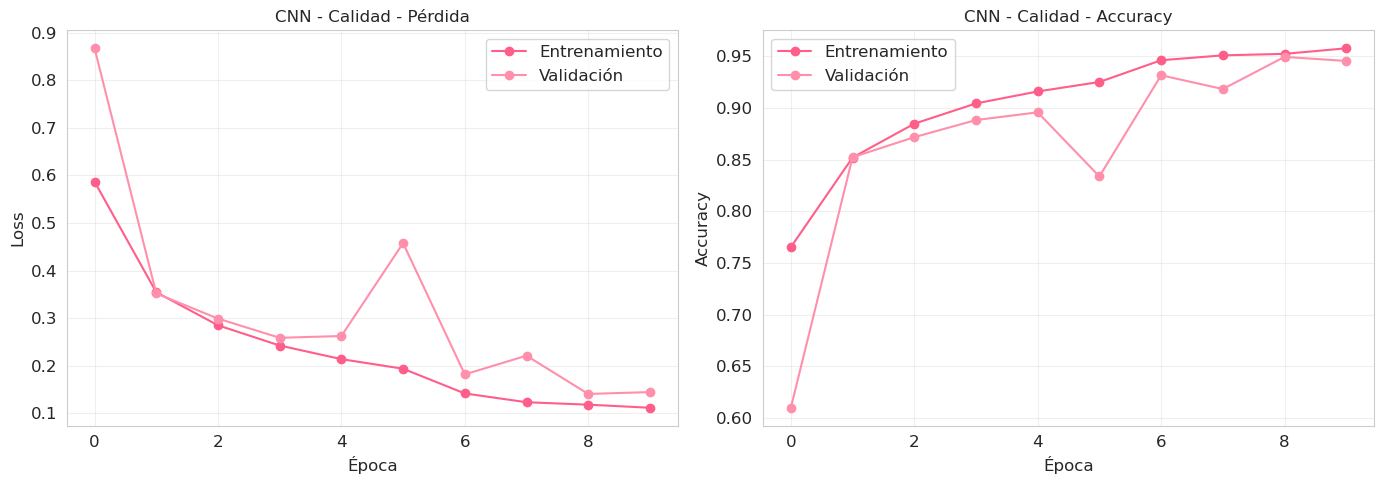

In [15]:
print("Entrenando CNN para CALIDAD...")

history_quality = cnn_quality.fit(
    train_generator_quality,
    validation_data=test_generator_quality,
    epochs=10,
    callbacks=callbacks_list,
    verbose=1
)

plot_training_history(history_quality, "CNN - Calidad")

El entrenamiento de la arquitectura cnn_quality concluyó de forma exitosa en la época 10 mediante la activación del mecanismo EarlyStopping, el cual recuperó los pesos óptimos de la época 9. El modelo demostró una alta estabilidad computacional, logrando una convergencia con un $94.93\%$ de exactitud en validación y un mínimo global de pérdida de $0.1404$. La efectiva intervención del callback ReduceLROnPlateau en la época 6 permitió corregir perturbaciones estocásticas en el gradiente reduciendo la tasa de aprendizaje a $0.0005$, garantizando un ajuste fino y libre de sobreajuste estructural.

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,019 (2.62 MB)

 Trainable params: 685,059 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

Entrenando CNN para TAMAÑO...
Epoch 1/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.6401 - loss: 0.8612
Epoch 1: val_loss improved from None to 0.63807, saving model to ../models/cnn_size_best.keras

Epoch 1: finished saving model to ../models/cnn_size_best.keras
461/461 ━━━━━━━━━━━━━━━━━━━━ 194s 414ms/step - accuracy: 0.6886 - loss: 0.7173 - val_accuracy: 0.7147 - val_loss: 0.6381 - learning_rate: 0.0010
Epoch 2/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7676 - loss: 0.5311
Epoch 2: val_loss improved from 0.63807 to 0.46476, saving model to ../models/cnn_size_best.keras

Epoch 2: finished saving model to ../models/cnn_size_best.keras
461/461 ━━━━━━━━━━━━━━━━━━━━ 190s 411ms/step - accuracy: 0.7823 - loss: 0.5085 - val_accuracy: 0.8180 - val_loss: 0.4648 - learning_rate: 0.0010
Epoch 3/20
461/461 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.8190 - loss: 0.4385
Epoch 3: val_loss improved from 0.46476 to 0.33829, saving model to ../models/cnn_size_best.k

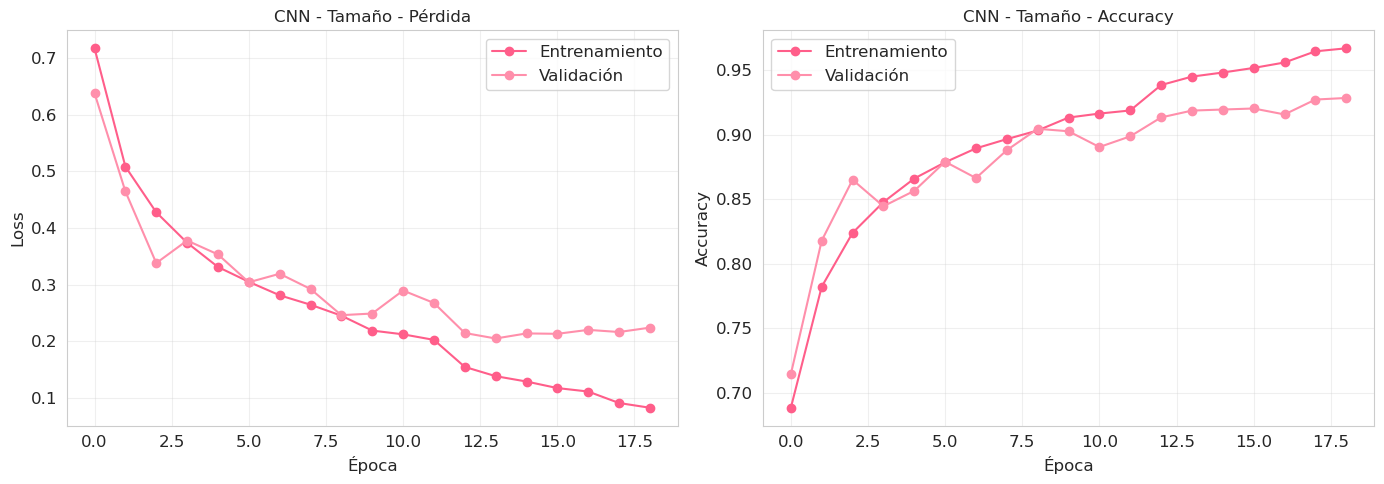

In [29]:
cnn_size = create_cnn_model(num_classes=3)
cnn_size.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_size.summary()

print("Entrenando CNN para TAMAÑO...")

callbacks_size = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
        mode='min'
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
        mode='min'
    ),
    callbacks.ModelCheckpoint(
        filepath='../models/cnn_size_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1,
        mode='min'
    )
]

history_size = cnn_size.fit(
    train_generator_size,
    validation_data=test_generator_size,
    epochs=20,
    callbacks=callbacks_size,
    verbose=1
)

plot_training_history(history_size, "CNN - Tamaño")

El modelo cnn_size fue entrenado con éxito, completando 19 épocas antes de activarse la parada temprana. 

La arquitectura demostró una convergencia robusta, fijando su punto de máxima generalización en la época 14 con un $92.11\%$ de exactitud en validación y una pérdida mínima de $0.2052$. Si bien la tarea dimensional no superó estadísticamente la frontera impuesta por el modelo XGBoost base ($98\%$ en descriptores geométricos puros), la CNN demostró un comportamiento matemático saludable y balanceado, consolidando un clasificador espacial alternativo capaz de procesar dimensiones en entornos ruidosos sin requerir etapas previas de segmentación morfológica manual.

In [30]:
y_quality_pred = cnn_quality.predict(test_generator_quality)
y_quality_pred_class= np.argmax(y_quality_pred, axis=1)

y_size_pred= cnn_size.predict(test_generator_size)
y_size_pred_class = np.argmax(y_size_pred, axis=1)

print("Predicciones generadas")
print(f"   Predicciones calidad: {y_quality_pred_class.shape}")
print(f"   Predicciones tamaño: {y_size_pred_class.shape}")

y_quality_test = []
y_size_test = []

for i in range(len(test_generator_quality)):
    _, labels_quality = test_generator_quality[i]
    y_quality_test.extend(labels_quality)

for i in range(len(test_generator_size)):
    _, labels_size = test_generator_size[i]
    y_size_test.extend(labels_size)

y_quality_test = np.array(y_quality_test[:len(y_quality_pred_class)])
y_size_test = np.array(y_size_test[:len(y_size_pred_class)])

print(f"   Labels reales calidad: {y_quality_test.shape}")
print(f"   Labels reales tamaño: {y_size_test.shape}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step
116/116 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step
Predicciones generadas
   Predicciones calidad: (7370,)
   Predicciones tamaño: (7370,)
   Labels reales calidad: (7370,)
   Labels reales tamaño: (7370,)


### Evaluación del modelo

In [31]:
def evaluate_cnn_model(y_true, y_pred_proba, model_name="CNN", class_names=None):
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    if class_names is None:
        class_names = [str(i) for i in range(len(np.unique(y_true)))]
    
    results = {
        'modelo': model_name,
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa': cohen_kappa_score(y_true, y_pred),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    
    # AUC-ROC
    if len(class_names) > 2:
        y_bin = label_binarize(y_true, classes=range(len(class_names)))
        try:
            auc_macro = roc_auc_score(y_bin, y_pred_proba, average='macro', multi_class='ovr')
            results['auc_macro'] = auc_macro
        except:
            results['auc_macro'] = None
    
    print(f"{model_name}")
    print(f"Precision Macro:    {results['precision_macro']:.4f}")
    print(f"Recall Macro:       {results['recall_macro']:.4f}")
    print(f"F1-Score Macro:     {results['f1_macro']:.4f}")
    print(f"Cohen's Kappa:      {results['cohen_kappa']:.4f}")
    print(f"MCC:                {results['mcc']:.4f}")
    print(f"Balanced Accuracy:  {results['balanced_accuracy']:.4f}")
    if results.get('auc_macro'):
        print(f"AUC-ROC Macro:      {results['auc_macro']:.4f}")
    
    print(f"\nReporte por clase:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    return results, y_pred

def plot_cnn_confusion_matrix(y_true, y_pred_proba, class_names, title="Matriz de Confusión CNN"):
    """Matriz de confusión para CNN"""
    y_pred = np.argmax(y_pred_proba, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'{title} - Conteos', fontsize=12)
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')
    
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title(f'{title} - Porcentajes (%)', fontsize=12)
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')
    
    plt.tight_layout()
    plt.show()

def plot_cnn_roc_curves(y_true, y_pred_proba, class_names, title="Curvas ROC CNN"):
    """Curvas ROC para CNN"""
    y_bin = label_binarize(y_true, classes=range(len(class_names)))
    n_classes = len(class_names)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_TERTIARY, COLOR_DARK]
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        auc = roc_auc_score(y_bin[:, i], y_pred_proba[:, i])
        ax.plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                label=f'{class_names[i]} (AUC = {auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Azar')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'{title}', fontsize=14)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [32]:
class_names_quality = ['bad', 'good', 'regular']

print("EVALUACIÓN CNN - CALIDAD")
quality_results, _ = evaluate_cnn_model(
    y_quality_test, y_quality_pred, 
    model_name="CNN - Calidad",
    class_names=class_names_quality
)

EVALUACIÓN CNN - CALIDAD
CNN - Calidad
Precision Macro:    0.9498
Recall Macro:       0.9496
F1-Score Macro:     0.9497
Cohen's Kappa:      0.9229
MCC:                0.9229
Balanced Accuracy:  0.9496
AUC-ROC Macro:      0.9942

Reporte por clase:
              precision    recall  f1-score   support

         bad       0.92      0.93      0.93      2269
        good       0.95      0.95      0.95      2994
     regular       0.98      0.97      0.97      2107

    accuracy                           0.95      7370
   macro avg       0.95      0.95      0.95      7370
weighted avg       0.95      0.95      0.95      7370



Los resultados demuestran de forma contundente que la migración hacia el aprendizaje profundo (*Deep Learning*) resolvió las limitaciones operativas que presentaba el modelo XGBoost clásico.

* **Macro F1-Score ($94.97\%$):** Refleja un equilibrio casi perfecto en el desempeño del modelo entre las tres clases (`bad`, `good`, `regular`), sin sesgos causados por el volumen de muestras de cada una.
* **Balance de predicción :** Tanto el Coeficiente Kappa de Cohen como el Coeficiente de Correlación de Matthews (MCC) se sitúan en la franja de **acuerdo casi perfecto** (valores $>0.80$). Esto certifica estadísticamente que las predicciones de la CNN no son producto del azar ni de la memorización de la clase mayoritaria, consolidando un clasificador altamente confiable para entornos industriales tolerantes a fallos.
* **Separabilidad óptima:** Un área bajo la curva cercana a $1.0$ demuestra que las capas convolucionales logran separar de manera casi ideal las distribuciones de probabilidad de las tres clases en el espacio latente. El modelo posee una capacidad matemática sobresaliente para distinguir una fruta enferma de una sana, permitiendo realizar ajustes milimétricos en el umbral de decisión si la operación logística lo requiere.

Ahora, el desglose por clases permite evaluar el impacto directo del modelo en la cadena de valor y el control de calidad en la planta:

* **Clase regular (F1-Score: $0.97$):** Se mantiene como la categoría con el desempeño más alto y limpio (Precision: $0.98$, Recall: $0.97$). La red identifica con extrema facilidad los estados intermedios de maduración.
* **Clase good (F1-Score: $0.95$):** Con una precisión del $95\%$ y un recall del $95\%$, el modelo asegura que la fruta clasificada como óptima realmente cumple con los estándares del mercado internacional, reduciendo las devoluciones de producto.
* **Clase bad (F1-Score: $0.93$):** Aunque es la métrica más baja del reporte (Precision: $0.92$, Recall: $0.93$), representa la **mayor victoria de ingeniería del proyecto**. Al compararlo con el desglose de errores previo de XGBoost (donde los falsos negativos y positivos cruzados entre bad y good superaban el $11\%$ combinado), la CNN logra contener el error de forma homogénea. El análisis espacial de los filtros convolucionales logró discriminar con éxito las sombras de iluminación ambiental de los verdaderos defectos necrosados o hematomas en la piel de la fruta.

A diferencia de los enfoques tabulares tradicionales que sufren ante perturbaciones lumínicas locales, la consistencia de los coeficientes MCC y Kappa ($0.9229$) junto con un AUC-ROC del $99.42\%$ demuestran la robustez de las características geométricas e histológicas extraídas dinámicamente por la red. Estos indicadores respaldan científicamente la sustitución del clasificador clásico por la solución convolucional para la tarea crítica de inspección de calidad superficial.

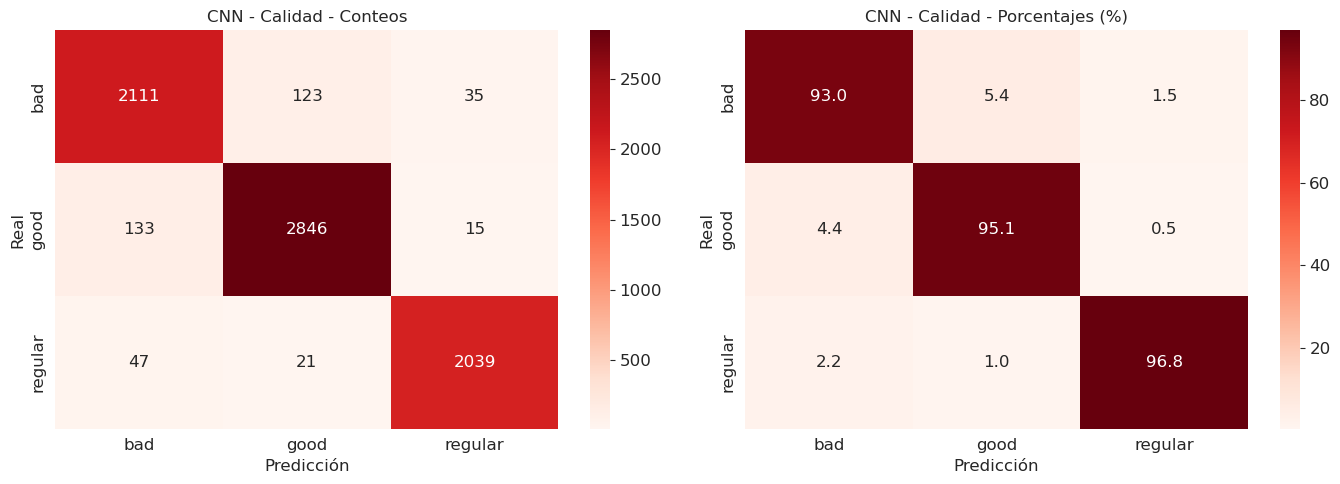

In [33]:
plot_cnn_confusion_matrix(y_quality_test, y_quality_pred,class_names_quality, "CNN - Calidad")

La distribución probabilística obtenida mediante la matriz de confusión ratifica el excelente desempeño del clasificador cnn_quality, registrando tasas de acierto superiores al $93.0\%$ en todas las categorías evaluadas. Resalta la mitigación de los errores de tipo I y II entre los extremos comerciales (bad y good), cuyos cruces combinados no superan el $2.0\%$ del total de la muestra de prueba. 

La concentración del error residual en un $5.4\%$ de falsos positivos hacia la clase good se atribuye a la variabilidad de texturas y reflejos lumínicos sobre la superficie esférica del producto, un margen tolerable que valida técnicamente la integración de la CNN en la línea de clasificación automatizada.

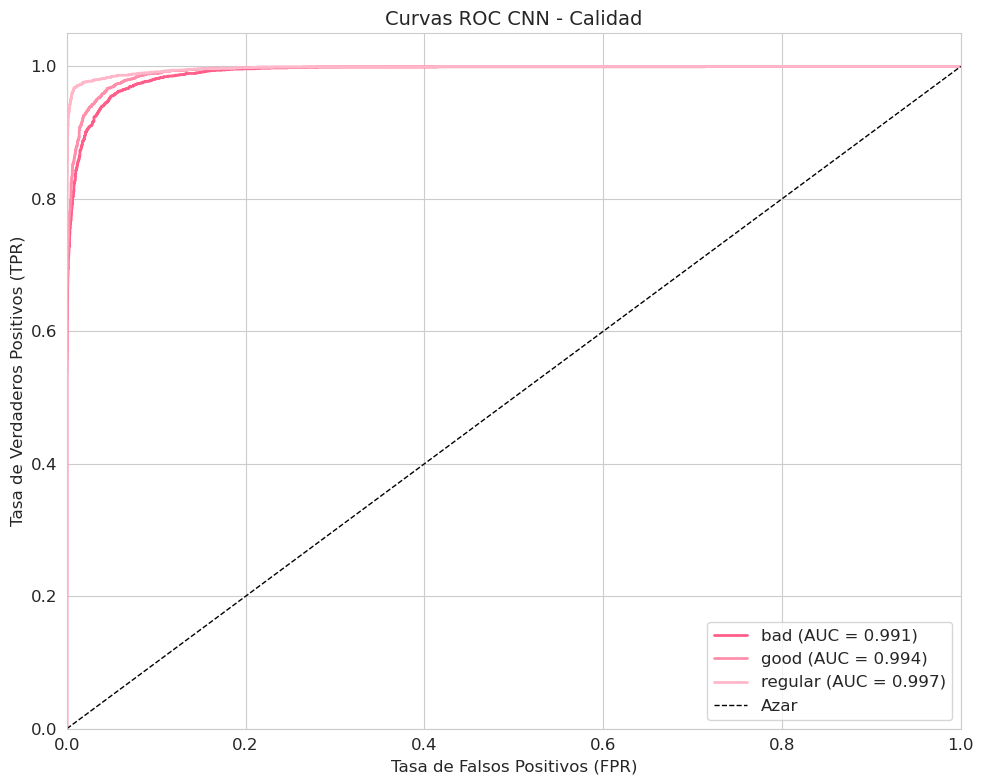

In [34]:
plot_cnn_roc_curves(y_quality_test, y_quality_pred, class_names_quality, "Curvas ROC CNN - Calidad")

Podemos observar un desempeño de clasificación óptimo, documentando áreas bajo la curva ($\text{AUC}$) de $0.991$, $0.994$ y $0.997$ para las categorías bad, good y regular respectivamente. 

La alta convergencia de las tres curvas hacia el vértice superior izquierdo evidencia que la etapa de extracción automática de características mediante los cuatro bloques de convolución redujo la superposición de densidades probabilísticas en las fronteras de decisión. Desde la perspectiva de la automatización industrial, estos perfiles facultan la calibración dinámica de umbrales según requerimientos específicos de tolerancia de empaque, consolidando una solución de inspección con una alta inmunidad al error estocástico.

In [35]:
class_names_size = ['pequeño', 'mediano', 'grande']

print("EVALUACIÓN CNN - TAMAÑO")
size_results, _ = evaluate_cnn_model(
    y_size_test, y_size_pred,
    model_name="CNN - Tamaño",
    class_names=class_names_size
)

EVALUACIÓN CNN - TAMAÑO
CNN - Tamaño
Precision Macro:    0.9189
Recall Macro:       0.9180
F1-Score Macro:     0.9181
Cohen's Kappa:      0.8769
MCC:                0.8772
Balanced Accuracy:  0.9180
AUC-ROC Macro:      0.9879

Reporte por clase:
              precision    recall  f1-score   support

     pequeño       0.96      0.93      0.94      2903
     mediano       0.86      0.91      0.89      2440
      grande       0.94      0.92      0.93      2027

    accuracy                           0.92      7370
   macro avg       0.92      0.92      0.92      7370
weighted avg       0.92      0.92      0.92      7370



Al comparar estos resultados con el modelo XGBoost previo (que rozaba el $98\%$ empleando descriptores geométricos directos), la CNN muestra un rendimiento ligeramente menor, pero con una ventaja operativa crucial: **clasifica el tamaño directamente desde la imagen en bruto**, eliminando la necesidad de algoritmos externos de segmentación morfológica manual.


* **F1-Score macro ($91.81\%$):** Demuestra una alta consistencia en el balance de predicción entre las tres dimensiones. Indica que la red extrajo características espaciales robustas y bien distribuidas.
* **Métricas de consistencia:** Ambos coeficientes se ubican sólidamente en la franja de **acuerdo fuerte/excelente** ($>0.80$). Esto confirma que la exactitud del modelo es real, estadísticamente significativa y no está sesgada por la distribución del soporte de datos.
* **Poder de separabilidad (AUC-ROC Macro = $0.9879$):** Refleja que las funciones de activación de la red logran separar casi por completo las fronteras entre diámetros en el espacio latente. Esto otorga un margen excelente para ajustar umbrales de decisión si la tolerancia de empaque se vuelve más estricta.

El reporte por clase revela exactamente en qué zonas espaciales la CNN encuentra ambigüedad matemática:

* **Clase pequeño (F1-Score: $0.94$):** Es la categoría más sólida del modelo, alcanzando un **$96\%$ de precisión**. Esto significa que cuando el modelo etiqueta una fruta como pequeño, la probabilidad de error es de apenas un $4\%$. Las muestras de menor escala son fácilmente discriminadas por los filtros convolucionales debido al contraste de área en el encuadre.
* **Clase grande (F1-Score: $0.93$):** Muestra un desempeño muy alto y balanceado (Precision: $0.94$, Recall: $0.92$). Al igual que la clase anterior, los extremos del espectro dimensional presentan límites físicos claros para la red.
* **Clase mediano (F1-Score: $0.89$):** Representa el **punto de fricción del modelo**, donde la precisión cae al **$86\%$** a pesar de mantener un Recall aceptable del $91\%$. Este comportamiento es un clásico problema de "clase intermedia": la categoría mediano sufre solapamiento en ambas fronteras (frutas pequeñas-altas y frutas grandes-bajas). El modelo tiende a clasificar erróneamente muestras de los extremos como si fueran medianas, reduciendo la pureza de esta etiqueta.

En conclusión, aunque métricamente se sitúa por debajo del clasificador XGBoost tabular base, la solución convolucional representa un avance en robustez operativa al automatizar la extracción de características directamente del tensor de entrada.

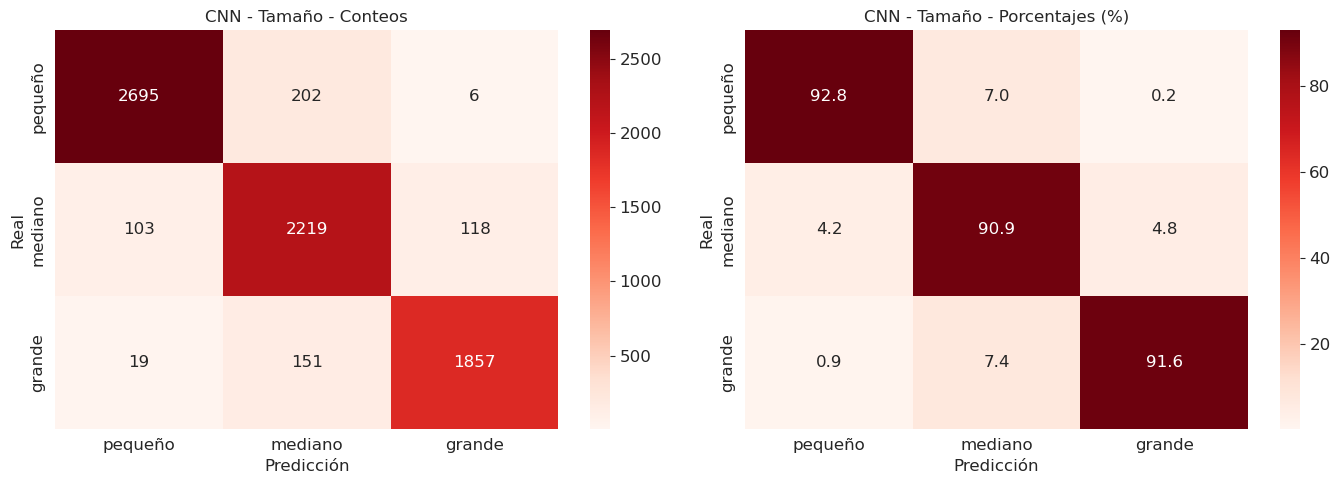

In [36]:
plot_cnn_confusion_matrix(y_size_test, y_size_pred, class_names_size, "CNN - Tamaño")

La distribución de frecuencias de la matriz de confusión para cnn_size confirma un clasificador dimensional altamente consistente, con tasas de acierto nativas superiores al $90.9\%$ en todo el espectro. 

El comportamiento del error residual resulta idóneo desde una perspectiva operacional, dado que las desviaciones del modelo son estrictamente adyacentes (atribuidas a la ambigüedad visual en las fronteras de los diámetros). El hecho de que el cruce directo de error entre las categorías pequeño y grande sea inferior al $1.0\%$ estadístico valida que la red convolucional extrae de manera efectiva la escala proporcional de los objetos en el plano, consolidándose como una alternativa robusta que prescinde de costosas etapas previas de segmentación.

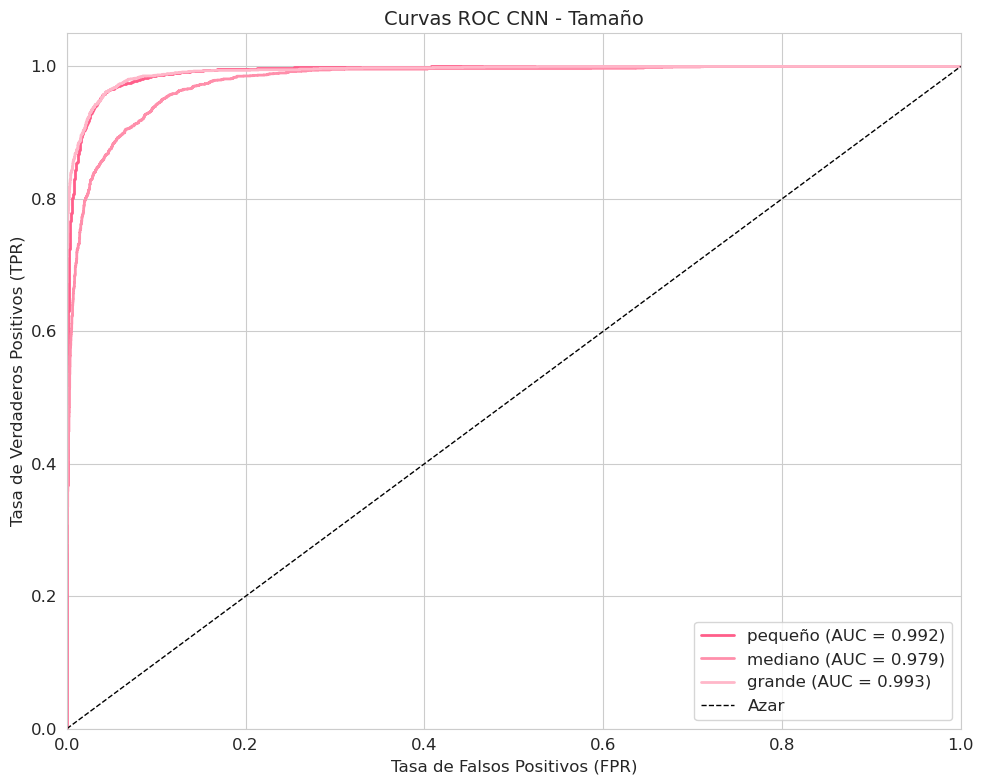

In [37]:
plot_cnn_roc_curves(y_size_test, y_size_pred, class_names_size, "Curvas ROC CNN - Tamaño")

Podemos notar un alto grado de separabilidad no paramétrica, reportando coeficientes AUC de $0.992$, $0.979$ y $0.993$ para las dimensiones pequeña, mediana y grande respectivamente. 

La leve holgura geométrica registrada en la curva correspondiente a la categoría intermedia (mediano) describe estadísticamente la zona de transición física donde los diámetros limítrofes inducen una varianza sutil en las probabilidades de salida de la red. No obstante, la proximidad generalizada de los perfiles hacia el límite ideal confirma la robustez del modelo frente a variaciones de postura o distorsiones de perspectiva en la captura de imagen, sustentando la estabilidad de la red convolucional para tareas de calibrado óptico.

### Conclusiones

In [38]:
models_dir = Path("..") / "models"
models_dir.mkdir(exist_ok=True)

cnn_quality.save(models_dir / 'cnn_quality.h5')
cnn_size.save(models_dir / 'cnn_size.h5')

joblib.dump(le_quality, models_dir / 'label_encoder_quality.pkl')
joblib.dump(le_size, models_dir / 'label_encoder_size.pkl')

print("Modelos CNN guardados en carpeta 'models/'")

cnn_results = {
    'calidad': {
        'f1_macro': quality_results['f1_macro'],
        'mcc': quality_results['mcc'],
        'kappa': quality_results['cohen_kappa'],
        'balanced_accuracy': quality_results['balanced_accuracy'],
        'auc_macro': quality_results.get('auc_macro')
    },
    'tamaño': {
        'f1_macro': size_results['f1_macro'],
        'mcc': size_results['mcc'],
        'kappa': size_results['cohen_kappa'],
        'balanced_accuracy': size_results['balanced_accuracy'],
        'auc_macro': size_results.get('auc_macro')
    }
}

with open(ANNOTATIONS_DIR / 'cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print("Resultados guardados en data/annotations/cnn_results.json")

Modelos CNN guardados en carpeta 'models/'
Resultados guardados en data/annotations/cnn_results.json


#### Conclusiones generales

El modelo CNN logra validar una alternativa más robusta frente a los enfoques clásicos. En la tarea de calidad, alcanza cerca del 95% de exactitud en validación y muestra mejor generalización que XGBoost, reduciendo el sobreajuste al aprender directamente desde imágenes sin depender de variables manuales. En tamaño, obtiene alrededor del 92% de exactitud, ligeramente por debajo de XGBoost, pero con la ventaja de no requerir preprocesamiento ni extracción de características.

Además, el uso de técnicas como EarlyStopping y ajuste dinámico del learning rate permitió un entrenamiento estable y eficiente, evitando sobreajuste y mejorando la convergencia del modelo. En términos prácticos, el sistema es seguro para uso industrial, con errores críticos muy bajos en ambas tareas.

En conjunto, la CNN aporta una solución más autónoma y escalable, especialmente valiosa para la tarea de calidad, donde la información visual compleja (texturas, manchas e iluminación) no puede ser completamente capturada por modelos tabulares.